In [ ]:
#the imports
import numpy as np
from sklearn.linear_model import LogisticRegression

In [ ]:
#loading the cleaned data from phase1
data = np.load('processed_cancer_data.npz')
X_train, X_test = data['X_train'], data['X_test']
y_train, y_test = data['y_train'], data['y_test']

In [4]:
#initializing and training the model
classifer = LogisticRegression(random_state=42)
classifer.fit(X_train, y_train)
print("LogisticRegression model successfully trained!")

LogisticRegression model successfully trained!


In [5]:
#imports for phase3 - evaluation metrics
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
#predicting outcomes for the unseen test data
y_pred = classifer.predict(X_test)

In [7]:
#calculating the core metrics
acc = accuracy_score(y_test, y_pred)
print(f'Overall Model Accuracy: {acc * 100:.2f}%\n')

print("Detailed Classification report: ")
print(classification_report(y_test, y_pred, target_names=['Benign (0)', 'Malignant(1)']))


Overall Model Accuracy: 97.37%

Detailed Classification report: 
              precision    recall  f1-score   support

  Benign (0)       0.97      0.99      0.98        71
Malignant(1)       0.98      0.95      0.96        43

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



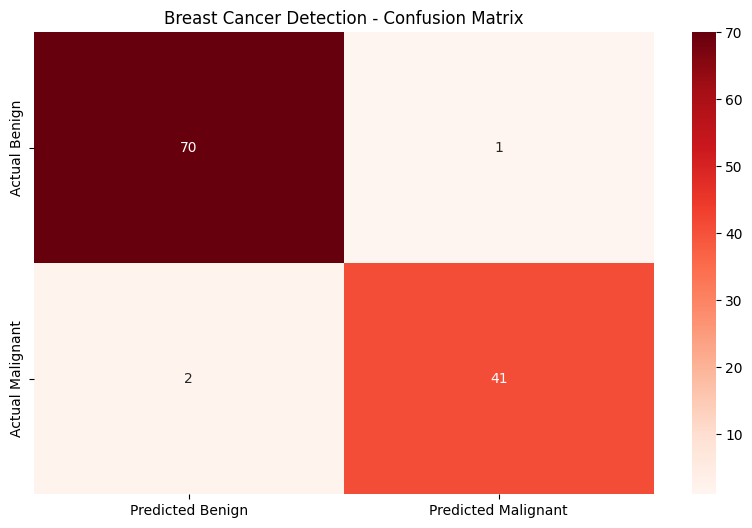

In [8]:
#visualizing the confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=['Predicted Benign', 'Predicted Malignant'], yticklabels=['Actual Benign', 'Actual Malignant'])
plt.title('Breast Cancer Detection - Confusion Matrix')
plt.show()

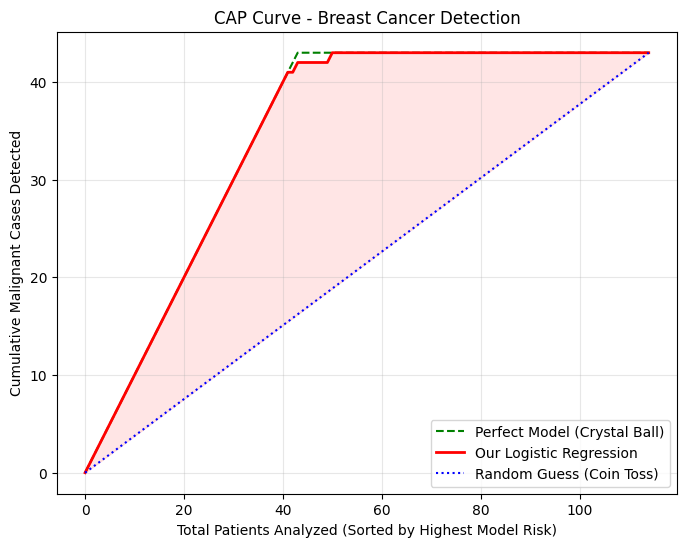

In [9]:
# 1. Get the PROBABILITIES, not just the final 0 or 1 predictions
# predict_proba gives us the exact % chance the model thinks a tumor is Malignant
y_pred_proba = classifer.predict_proba(X_test)[:, 1]

# 2. Sort the actual patients based on the model's predicted probabilities (Highest risk first)
sorted_indices = np.argsort(y_pred_proba)[::-1]
y_actual_sorted = y_test[sorted_indices]

# 3. Setup the numbers for our graph
total_patients = len(y_test)
total_malignant = np.sum(y_test) # In your case, this is 43

# X-axis: 0 to 114 patients
x_values = np.arange(0, total_patients + 1)

# Y-axis (Our Model): Cumulative sum of actual malignant cases found
y_model = np.append([0], np.cumsum(y_actual_sorted))

# Y-axis (Random Guess): A straight diagonal line
y_random = np.append([0], np.cumsum(np.full(total_patients, total_malignant / total_patients)))

# Y-axis (Perfect Model): Catches all 43 malignant cases perfectly in the first 43 tries, then flatlines
perfect_array = np.concatenate([np.ones(total_malignant), np.zeros(total_patients - total_malignant)])
y_perfect = np.append([0], np.cumsum(perfect_array))

# 4. Draw the Plot
plt.figure(figsize=(8, 6))
plt.plot(x_values, y_perfect, label='Perfect Model (Crystal Ball)', color='green', linestyle='--')
plt.plot(x_values, y_model, label='Our Logistic Regression', color='red', linewidth=2)
plt.plot(x_values, y_random, label='Random Guess (Coin Toss)', color='blue', linestyle=':')

plt.title('CAP Curve - Breast Cancer Detection')
plt.xlabel('Total Patients Analyzed (Sorted by Highest Model Risk)')
plt.ylabel('Cumulative Malignant Cases Detected')
plt.legend()
plt.grid(True, alpha=0.3)
plt.fill_between(x_values, y_model, y_random, color='red', alpha=0.1) # Highlights the value our model adds
plt.show()